In [1]:
import torch
import torch.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from typing import Tuple, Optional, List
from torch.func import vmap, jacrev
import torch.nn.functional as F
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#train score model

展示真实轨迹时间序列...


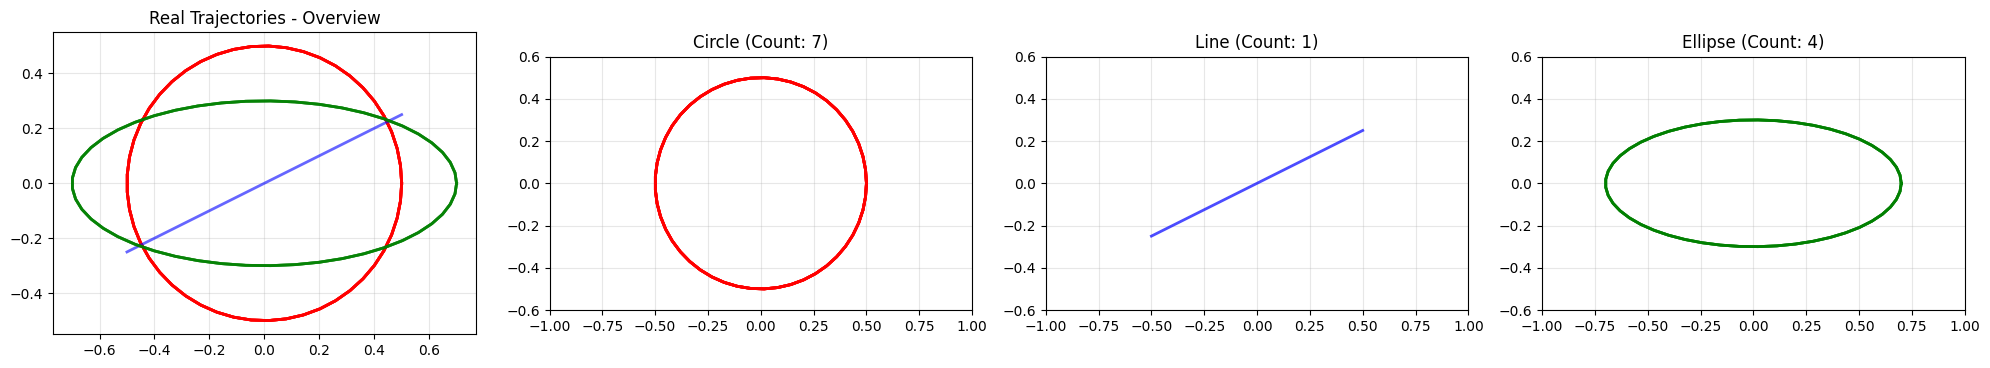

模型参数数量: 216,290


训练进度: 100%|██████████| 1000/1000 [00:05<00:00, 188.07it/s, Loss=0.043791]
C:\Users\ROG\AppData\Local\Temp\ipykernel_7436\3586364501.py:375: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.savefig('score_matching_loss.png')
C:\Users\ROG\AppData\Local\Temp\ipykernel_7436\3586364501.py:375: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.savefig('score_matching_loss.png')
C:\Users\ROG\AppData\Local\Temp\ipykernel_7436\3586364501.py:375: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.savefig('score_matching_loss.png')
C:\Users\ROG\AppData\Local\Temp\ipykernel_7436\3586364501.py:375: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.savefig('score_matching_loss.png')
C:\Users\ROG\AppData\Local\Temp\ipykernel_7436\3586364501.py:375: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missin

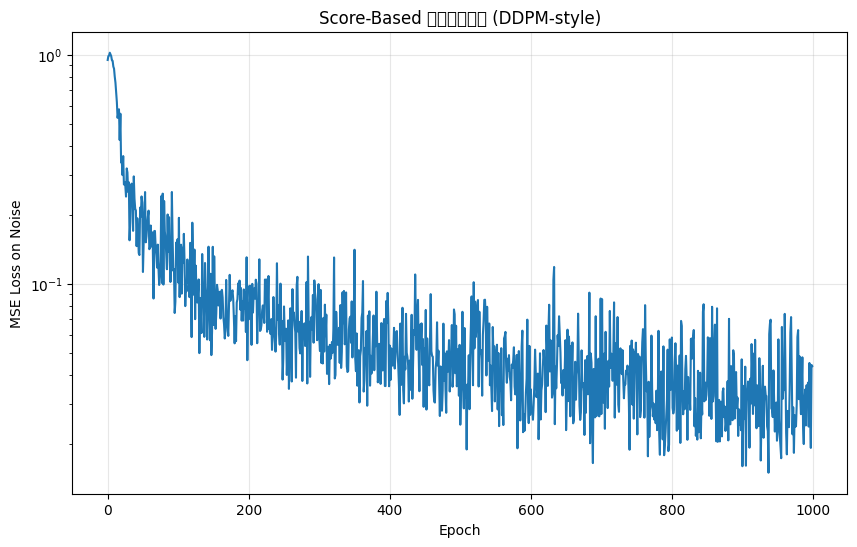

生成新的轨迹时间序列...


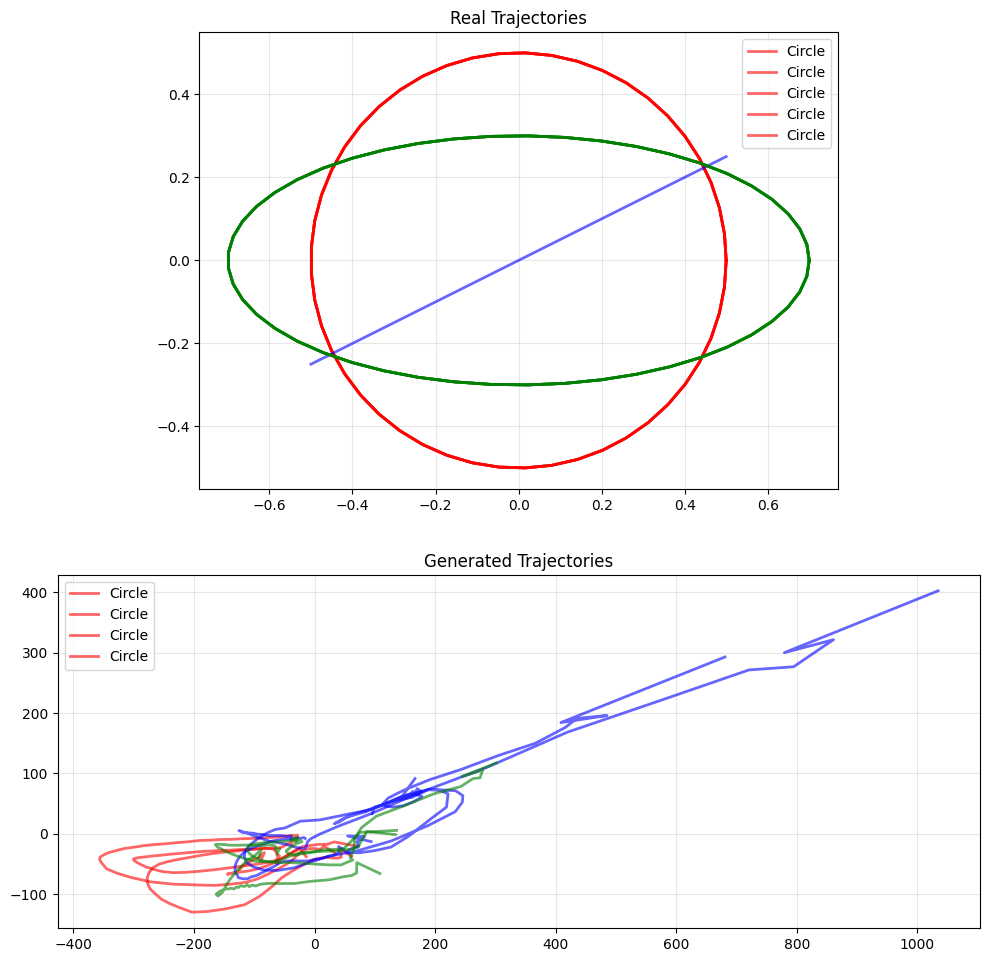

In [2]:
class Sampleable(ABC):
    @abstractmethod
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        pass

class ConditionalProbabilityPath(nn.Module, ABC):
    def __init__(self, p_simple: Sampleable, p_data: Sampleable):
        super().__init__()
        self.p_simple = p_simple
        self.p_data = p_data

    def sample_marginal_path(self, t: torch.Tensor) -> torch.Tensor:
        num_samples = t.shape[0]
        z, _ = self.sample_conditioning_variable(num_samples)
        x, _ = self.sample_conditional_path(z, t)
        return x

    @abstractmethod
    def sample_conditioning_variable(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        pass

    @abstractmethod  
    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor, noise: torch.Tensor = None) -> Tuple[torch.Tensor, torch.Tensor]:
        pass


class SimpleTrajectoryDataset(Sampleable):
    def __init__(self, seq_len=50, dim=2, num_classes=3):
        self.seq_len = seq_len
        self.dim = dim
        self.num_classes = num_classes
    
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        labels = torch.randint(0, self.num_classes, (num_samples,))
        trajectories = []
        
        for label in labels:
            label_val = label.item()
            t = np.linspace(0, 2*np.pi, self.seq_len)
            
            if label_val == 0:  # 圆形时间序列
                x = np.cos(t) * 0.5
                y = np.sin(t) * 0.5
                traj = np.stack([x, y], axis=-1)
            elif label_val == 1:  # 直线时间序列
                x = np.linspace(-0.5, 0.5, self.seq_len)
                y = x * 0.5
                traj = np.stack([x, y], axis=-1)
            else:  # 椭圆时间序列
                x = np.cos(t) * 0.7
                y = np.sin(t) * 0.3
                traj = np.stack([x, y], axis=-1)
            
            trajectories.append(traj)
        
        trajectories = torch.tensor(np.array(trajectories), dtype=torch.float32).to(device)
        return trajectories, labels.to(device)

class TrajectoryNoise(Sampleable):
    def __init__(self, seq_len=50, dim=2):
        self.seq_len = seq_len
        self.dim = dim
    
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        trajectories = torch.randn(num_samples, self.seq_len, self.dim).to(device)
        return trajectories, None



class Alpha(ABC):
    def __init__(self):
        assert torch.allclose(self(torch.zeros(1,1,1)), torch.zeros(1,1,1))
        assert torch.allclose(self(torch.ones(1,1,1)), torch.ones(1,1,1))
    
    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        pass
    
    @abstractmethod
    def dt(self, t: torch.Tensor) -> torch.Tensor:
        pass
    
class Beta(ABC):
    def __init__(self):
        assert torch.allclose(self(torch.zeros(1,1,1)), torch.ones(1,1,1))
        assert torch.allclose(self(torch.ones(1,1,1)), torch.zeros(1,1,1))
    
    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        pass
    
    @abstractmethod
    def dt(self, t: torch.Tensor) -> torch.Tensor:
        pass

class LinearAlpha(Alpha):
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        return t
    
    def dt(self, t: torch.Tensor) -> torch.Tensor:
        return torch.ones_like(t)
        
class LinearBeta(Beta):
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        return 1-t
        
    def dt(self, t: torch.Tensor) -> torch.Tensor:
        return - torch.ones_like(t)



class FourierEncoder(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        assert dim % 2 == 0
        self.half_dim = dim // 2
        self.register_buffer('weights', torch.randn(1, self.half_dim))

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        t = t.view(-1, 1)
        freqs = t * self.weights * 2 * math.pi
        sin_embed = torch.sin(freqs)
        cos_embed = torch.cos(freqs)
        return torch.cat([sin_embed, cos_embed], dim=-1) * math.sqrt(2)

class SimpleTrajectoryUNet(nn.Module):
    def __init__(self, 
                 seq_len: int = 50,
                 input_dim: int = 2,
                 hidden_dims: List[int] = [64, 128],
                 t_embed_dim: int = 64,
                 y_embed_dim: int = 32,
                 num_classes: int = 3): 
        super().__init__()
        
        self.input_proj = nn.Linear(input_dim, hidden_dims[0])
        self.time_embedder = FourierEncoder(t_embed_dim)
        self.y_embedder = nn.Embedding(num_classes, y_embed_dim)
        self.time_proj = nn.Linear(t_embed_dim, hidden_dims[0])
        self.y_proj = nn.Linear(y_embed_dim, hidden_dims[0])

        self.encoder_convs = nn.ModuleList()
        self.downsample_layers = nn.ModuleList()
        
        for i in range(len(hidden_dims) - 1):
            self.encoder_convs.append(
                nn.Sequential(
                    nn.Conv1d(hidden_dims[i], hidden_dims[i], kernel_size=3, padding=1),
                    nn.SiLU(),
                    nn.Conv1d(hidden_dims[i], hidden_dims[i], kernel_size=3, padding=1),
                    nn.SiLU()
                )
            )
            self.downsample_layers.append(
                nn.Conv1d(hidden_dims[i], hidden_dims[i+1], kernel_size=3, stride=2, padding=1)
            )
        
        self.mid_conv = nn.Sequential(
            nn.Conv1d(hidden_dims[-1], hidden_dims[-1], kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv1d(hidden_dims[-1], hidden_dims[-1], kernel_size=3, padding=1),
            nn.SiLU()
        )
        
        self.upsample_layers = nn.ModuleList()
        self.decoder_convs = nn.ModuleList()
        
        for i in range(len(hidden_dims) - 1, 0, -1):
            in_channels = hidden_dims[i-1] * 2
            
            self.upsample_layers.append(
                nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
                    nn.Conv1d(hidden_dims[i], hidden_dims[i-1], kernel_size=3, padding=1)
                )
            )
            self.decoder_convs.append(
                nn.Sequential(
                    nn.Conv1d(in_channels, hidden_dims[i-1], kernel_size=3, padding=1),
                    nn.SiLU(),
                    nn.Conv1d(hidden_dims[i-1], hidden_dims[i-1], kernel_size=3, padding=1),
                    nn.SiLU()
                )
            )
        
        self.output_proj = nn.Linear(hidden_dims[0], input_dim)

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        bs, seq_len, input_dim = x.shape

        if t.dim() == 4:
            t = t.squeeze(-1)
        
        t_embed = self.time_embedder(t)
        y_embed = self.y_embedder(y)
        
        t_proj = self.time_proj(t_embed).unsqueeze(-1)
        y_proj = self.y_proj(y_embed).unsqueeze(-1)
        
        x = self.input_proj(x)
        x = x.transpose(1, 2)
        
        x = x + t_proj + y_proj
        
        skip_connections = []
        for conv, downsample in zip(self.encoder_convs, self.downsample_layers):
            x = conv(x)
            skip_connections.append(x)
            x = downsample(x)

        x = self.mid_conv(x)

        for upsample, conv in zip(self.upsample_layers, self.decoder_convs):
            x = upsample(x)
            skip = skip_connections.pop()
            
            if x.shape[-1] != skip.shape[-1]:
                skip = skip[:, :, :x.shape[-1]]
            
            x = torch.cat([x, skip], dim=1)
            x = conv(x)

        x = x.transpose(1, 2)
        x = self.output_proj(x)
        
        # 返回预测的噪声 (epsilon_hat)
        return x


class TrajectoryConditionalProbabilityPath(ConditionalProbabilityPath):
    def __init__(self, p_simple: Sampleable, p_data: Sampleable, 
                 alpha: Alpha, beta: Beta):
        super().__init__(p_simple, p_data)
        self.alpha = alpha
        self.beta = beta
    
    def sample_conditioning_variable(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        z, y = self.p_data.sample(num_samples)
        return z, y
    
    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor, noise: torch.Tensor = None) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Samples from the conditional distribution p_t(x|z)
        x_t = alpha_t * z + beta_t * noise
        Returns: (x_t, noise)
        """
        num_samples = z.shape[0]
        
        if noise is None:
            noise, _ = self.p_simple.sample(num_samples) # (num_samples, seq_len, dim)
        
        alpha_t = self.alpha(t).view(-1, 1, 1)
        beta_t = self.beta(t).view(-1, 1, 1)
        
        x_t = alpha_t * z + beta_t * noise
        
        return x_t, noise
    
    @torch.no_grad()
    def conditional_vector_field(self, x_t: torch.Tensor, z: torch.Tensor, t: torch.Tensor, eps: float = 1e-5) -> torch.Tensor:
        """
        Score-based Model 训练不需要此函数。
        """
        raise NotImplementedError("This function is not used in Score-based training.")




def plot_trajectories(trajectories, labels, title="Trajectories"):
    
    class_names = ['Circle', 'Line', 'Ellipse']
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    colors = ['red', 'blue', 'green']
    
    # 总览
    for class_idx in range(3):
        mask = labels == class_idx
        if mask.sum() > 0:
            class_trajs = trajectories[mask]
            for traj in class_trajs:
                axes[0].plot(traj[:, 0], traj[:, 1], color=colors[class_idx], alpha=0.6, linewidth=2)
    axes[0].set_title(f'{title} - Overview')
    axes[0].set_aspect('equal')
    axes[0].grid(True, alpha=0.3)
    
    # 分类别显示
    for class_idx in range(3):
        mask = labels == class_idx
        if mask.sum() > 0:
            class_trajs = trajectories[mask]
            for traj in class_trajs:
                axes[class_idx + 1].plot(traj[:, 0], traj[:, 1], color=colors[class_idx], alpha=0.7, linewidth=2)
        axes[class_idx + 1].set_title(f'{class_names[class_idx]} (Count: {mask.sum()})')
        axes[class_idx + 1].set_aspect('equal')
        axes[class_idx + 1].grid(True, alpha=0.3)
        axes[class_idx + 1].set_xlim(-1, 1)
        axes[class_idx + 1].set_ylim(-0.6, 0.6)
    
    plt.tight_layout()
    plt.savefig('trajectories.png')
    plt.show()

# 训练函数 (修正为 Score-based Loss)

def train_diffusion_model():
  
    # 创建数据集
    trajectory_data = SimpleTrajectoryDataset(seq_len=50, dim=2, num_classes=3)
    trajectory_noise = TrajectoryNoise(seq_len=50, dim=2)
    
    # 创建扩散系数
    alpha = LinearAlpha()
    beta = LinearBeta()
    
    # 创建条件概率路径
    cond_path = TrajectoryConditionalProbabilityPath(trajectory_noise, trajectory_data, alpha, beta)
    
    # 可视化真实数据
    print("展示真实轨迹时间序列...")
    real_trajs, real_labels = trajectory_data.sample(12)
    plot_trajectories(real_trajs.cpu(), real_labels.cpu(), "Real Trajectories")
    
    # 创建U-Net模型
    unet = SimpleTrajectoryUNet(num_classes=3).to(device)
    print(f"模型参数数量: {sum(p.numel() for p in unet.parameters()):,}")
    
    # 优化器和损失函数
    optimizer = torch.optim.Adam(unet.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    
    # 训练参数
    num_epochs = 1000
    batch_size = 32
    losses = []
    
    
    pbar = tqdm(range(num_epochs), desc="训练进度")
    
    for epoch in pbar:
        # 随机扩散时间步 (避免 t=0 导致除零)
        t = torch.rand(batch_size, 1, 1).to(device) * 0.999 + 0.001  # (batch, 1, 1) 范围 [0.001, 1.0]
        
        # 1. Score-Based (DDPM-style) 训练目标：预测噪声 (epsilon)
        
        # 采样数据 (z/x0) 和标签 (y)
        z, y = cond_path.sample_conditioning_variable(batch_size)
        
        # 计算加噪轨迹 (xt) 和实际噪声 (noise)
        x_t, noise = cond_path.sample_conditional_path(z, t)
        
        # U-Net预测噪声 (epsilon_hat)
        pred_noise = unet(x_t, t, y)
        
        # DDPM 损失 (MSE between predicted noise and true noise)
        loss = F.mse_loss(pred_noise, noise)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        pbar.set_postfix({'Loss': f'{loss.item():.6f}'})
    
    # 训练损失曲线
    plt.figure(figsize=(10, 6))
    plt.plot(losses)
    plt.title('Score-Based 训练损失曲线 (DDPM-style)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss on Noise')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.savefig('score_matching_loss.png')
    plt.show()
    
    return unet, cond_path, losses


def generate_trajectories(unet, cond_path, num_samples: int = 12, num_steps: int = 50, eps: float = 1e-5):
    """
    使用预测的噪声（Score-Based/DDPM 风格）通过 Rectified Flow ODE 采样生成轨迹。
    """
    print("生成新的轨迹时间序列...")
    unet.eval()
    
    with torch.no_grad():
        # 从噪声开始
        x = torch.randn(num_samples, 50, 2).to(device)
        
        # 指定生成的轨迹类别
        labels = torch.arange(3).repeat(num_samples // 3 + 1)[:num_samples].to(device)
        
        # ODE 求解：使用 Euler 方法积分速度场
        dt = 1.0 / num_steps
        
        for i in range(num_steps):
            t_val = i / num_steps  # 从 0 到 1
            t = torch.full((num_samples, 1, 1), t_val).to(device)
            
            # 1. U-Net预测噪声 (epsilon_hat)
            pred_noise = unet(x, t, labels)
            
            # 2. 估计目标数据 x0 (z_hat)
            alpha_t = cond_path.alpha(t).view(-1, 1, 1)
            beta_t = cond_path.beta(t).view(-1, 1, 1)
            
            alpha_safe = torch.clamp(alpha_t, min=eps)
            # 预测的 z_hat (即 x0_hat)
            z_hat = (x - beta_t * pred_noise) / alpha_safe
            
            # 3. 计算 Rectified Flow 速度场 (v_t) 驱动的预测速度
            # Rectified Flow velocity: v_t = (z_hat - x_t) / (1 - t)
            # 1-t 是 beta_t
            beta_safe = torch.clamp(beta_t, min=eps)
            v_t = (z_hat - x) / beta_safe
            
            # Euler 积分：x_{t+dt} = x_t + v_t * dt
            x = x + v_t * dt
        
        return x.cpu(), labels.cpu()


def main():
    
    # 训练模型 (Score-Based 损失)
    trained_unet, cond_path, losses = train_diffusion_model()
    
    # 生成轨迹 (PF-ODE 采样)
    generated_trajs, gen_labels = generate_trajectories(trained_unet, cond_path)
    
    # 对比真实和生成轨迹
    real_trajs, real_labels = cond_path.p_data.sample(12)
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    
    class_names = ['Circle', 'Line', 'Ellipse']
    colors = ['red', 'blue', 'green']
    titles_map = {0: 'Real Trajectories', 1: 'Generated Trajectories'}
    
    # 真实轨迹
    for class_idx in range(3):
        mask = real_labels.cpu() == class_idx
        if mask.sum() > 0:
            class_trajs = real_trajs.cpu()[mask]
            for traj in class_trajs:
                axes[0].plot(traj[:, 0], traj[:, 1], color=colors[class_idx], alpha=0.6, linewidth=2, label=class_names[class_idx] if class_idx == 0 else None)
    axes[0].set_title(titles_map[0])
    axes[0].set_aspect('equal')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # 生成轨迹
    for class_idx in range(3):
        mask = gen_labels == class_idx
        if mask.sum() > 0:
            class_trajs = generated_trajs[mask]
            for traj in class_trajs:
                axes[1].plot(traj[:, 0], traj[:, 1], color=colors[class_idx], alpha=0.6, linewidth=2, label=class_names[class_idx] if class_idx == 0 else None)
    axes[1].set_title(titles_map[1])
    axes[1].set_aspect('equal')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('comparison_trajectories.png')
    plt.show()
    
    
if __name__ == "__main__":
    main()